# Error Analysis — Phase 6

Post-modeling error analysis for the WiDS Wildfire Time-to-Threat pipeline. Uses OOF predictions from the best Phase 6 model/ensemble to answer:

1. **Which predictions fail most?** Identify worst-Brier samples and look for shared features.
2. **Temporal error patterns** — do errors cluster by hour or month?
3. **Distance-band error patterns** — does the model struggle near or far from evac zones?
4. **Calibration at each horizon** — are predicted probabilities well-calibrated?
5. **Residuals by feature group** — which feature types correlate with high error?

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve

sns.set_theme(style="whitegrid", palette="muted")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    plt.gcf().savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

HORIZONS = [12, 24, 48, 72]
PROB_COLS = [f"prob_{h}h" for h in HORIZONS]

# Load features + targets
train = pd.read_parquet("../data/features/train_features.parquet")
y = train[["time_to_hit_hours", "event"]]

# Pick best Phase 6 model from marker file; fall back to GBS baseline if ensemble not built yet
best_name = "gradient_boosted_survival"
marker = Path("../models/phase6_best.txt")
if marker.is_file():
    best_name = marker.read_text(encoding="utf-8").strip()

oof_path = Path(f"../models/oof_predictions_{best_name}.parquet")
if not oof_path.is_file():
    # Try ensemble OOF reconstruction via weighted average on members
    members_oof = sorted(Path("../models").glob("oof_predictions_*.parquet"))
    if not members_oof:
        raise FileNotFoundError(
            "No OOF predictions found. Run `make ensemble` first."
        )
    oof_path = members_oof[0]
    best_name = oof_path.stem.replace("oof_predictions_", "")

oof = pd.read_parquet(oof_path)
print(f"Analyzing model: {best_name}")
print(f"OOF predictions shape: {oof.shape}")
print(oof.describe().round(3))

Analyzing model: gradient_boosted_survival
OOF predictions shape: (221, 4)
       prob_12h  prob_24h  prob_48h  prob_72h
count   221.000   221.000   221.000   221.000
mean      0.247     0.309     0.325     0.361
std       0.371     0.416     0.423     0.421
min       0.011     0.026     0.035     0.052
25%       0.013     0.030     0.039     0.079
50%       0.014     0.036     0.045     0.084
75%       0.518     0.815     0.888     0.975
max       1.000     1.000     1.000     1.000


## 1. Per-Sample Brier Contribution

Compute squared-error per horizon per sample, then mean across horizons. This is the per-sample loss that drives the CV Brier score.

Mean per-sample Brier: 0.02438
Median: 0.00232
Max: 0.49436


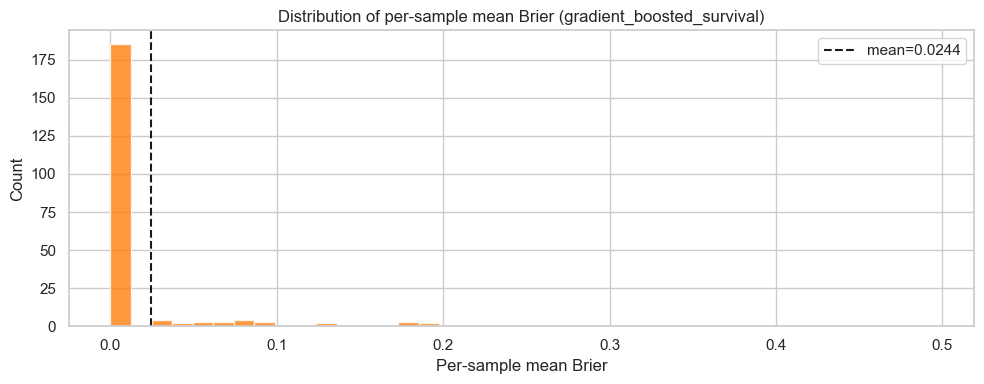

In [2]:
T = y["time_to_hit_hours"].values
E = y["event"].values

labels = np.column_stack(
    [((E == 1) & (T <= h)).astype(np.int32) for h in HORIZONS]
)
preds_arr = oof[PROB_COLS].values

# Per-sample mean Brier across 4 horizons
per_sample_brier = np.mean((preds_arr - labels) ** 2, axis=1)

err_df = train.copy()
err_df["brier_sample"] = per_sample_brier
err_df["label_72h"] = labels[:, 3]
err_df["pred_72h"] = preds_arr[:, 3]
err_df["abs_err_72h"] = np.abs(preds_arr[:, 3] - labels[:, 3])

print(f"Mean per-sample Brier: {per_sample_brier.mean():.5f}")
print(f"Median: {np.median(per_sample_brier):.5f}")
print(f"Max: {per_sample_brier.max():.5f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(per_sample_brier, bins=40, color="tab:orange", alpha=0.8)
ax.set_xlabel("Per-sample mean Brier")
ax.set_ylabel("Count")
ax.set_title(f"Distribution of per-sample mean Brier ({best_name})")
ax.axvline(per_sample_brier.mean(), color="k", linestyle="--",
           label=f"mean={per_sample_brier.mean():.4f}")
ax.legend()
plt.tight_layout()
save_fig("error_per_sample_brier")
plt.show()

## 2. Worst 15 Predictions

Rank samples by per-sample Brier contribution; inspect features.

In [3]:
worst = err_df.nlargest(15, "brier_sample")[
    [
        "event_id", "brier_sample", "event", "time_to_hit_hours",
        "pred_72h", "dist_min_ci_0_5h", "closing_speed_m_per_h",
        "alignment_abs", "area_first_ha", "is_closing", "is_growing",
    ]
].round(4)
print("Worst 15 OOF predictions:")
worst

Worst 15 OOF predictions:


,event_id,brier_sample,event,time_to_hit_hours,pred_72h,dist_min_ci_0_5h,closing_speed_m_per_h,alignment_abs,area_first_ha,is_closing,is_growing
108,52259907,0.4944,1,43.8467,1.0000,2297.2073,0.0,0.9691,21.8293,0,0
136,63182365,0.4460,1,45.3361,1.0000,2941.6705,0.0,0.0000,1951.6139,0,0
81,42731036,0.3856,1,66.9205,0.8950,2283.9424,0.0,0.0000,6.8015,0,0
143,66725353,0.3449,1,55.1706,0.8618,1458.4215,0.0,0.0000,2.0621,0,0
9,15743535,0.2748,1,54.6381,0.9200,1995.0424,0.0,0.0000,5.2185,0,0
32,22620173,0.2543,1,37.6167,0.9395,2035.1786,0.0,0.0000,17.7723,0,0
152,69938994,0.1933,1,3.6674,0.9207,1373.4880,0.0,0.0000,6.4649,0,0
1,11757157,0.1912,1,22.0481,1.0000,2930.9260,0.0,0.5689,8.9467,0,0
188,83950561,0.1797,1,14.3234,0.9987,1181.2235,0.0,0.0000,424.9636,0,0
197,86806129,0.1797,1,21.5295,0.9987,1950.3168,0.0,0.0000,457.4811,0,0


## 3. Worst-vs-Rest Feature Comparison

Compare mean feature values between the top-20 worst predictions and the remaining samples. Features with large differences point to systematic model weaknesses.

In [4]:
meta_cols = {"event_id", "time_to_hit_hours", "event",
             "brier_sample", "label_72h", "pred_72h", "abs_err_72h"}
feature_cols = [c for c in err_df.columns if c not in meta_cols]

is_worst = err_df["brier_sample"] >= err_df["brier_sample"].quantile(0.90)

worst_means = err_df.loc[is_worst, feature_cols].mean()
rest_means = err_df.loc[~is_worst, feature_cols].mean()

comp = pd.DataFrame({
    "worst10pct_mean": worst_means,
    "rest_mean": rest_means,
})
comp["abs_diff"] = (comp["worst10pct_mean"] - comp["rest_mean"]).abs()
# Normalize by rest std for comparability
rest_std = err_df.loc[~is_worst, feature_cols].std().replace(0, np.nan)
comp["std_diff"] = (comp["worst10pct_mean"] - comp["rest_mean"]) / rest_std
comp = comp.sort_values("std_diff", key=lambda s: s.abs(), ascending=False)

print("Top 15 features with largest standardized difference (worst-10% vs rest):")
comp.head(15).round(3)

Top 15 features with largest standardized difference (worst-10% vs rest):


,worst10pct_mean,rest_mean,abs_diff,std_diff
dist_bin,0.000,1.116,1.116,-1.416
dist_min_log,7.656,10.472,2.816,-1.366
dist_min_ci_0_5h,2308.604,138581.483,136272.879,-0.776
is_daytime,0.565,0.283,0.282,0.625
log1p_area_first,3.637,4.805,1.168,-0.561
hour_cos,0.218,0.489,0.271,-0.515
hour_sin,-0.674,-0.373,0.301,-0.509
dt_first_last_0_5h,0.243,1.065,0.823,-0.457
event_start_dayofweek,2.087,2.929,0.842,-0.424
num_perimeters_0_5h,1.130,2.172,1.041,-0.385


## 4. Error by Distance Band

Does the model struggle more with far-away or near-threat fires?

OOF error by distance band:
                brier   n  hit_rate
dist_band                          
Q1 (closest)   0.0786  56    1.0000
Q2             0.0133  55    0.2364
Q3             0.0023  55    0.0000
Q4 (farthest)  0.0023  55    0.0000


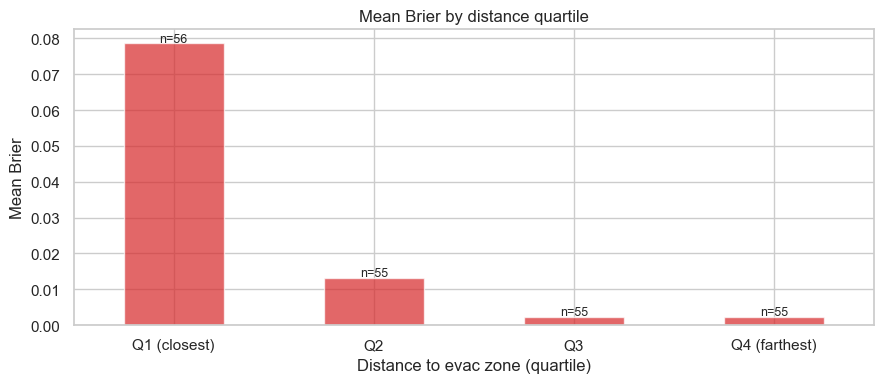

In [5]:
err_df["dist_band"] = pd.qcut(
    err_df["dist_min_ci_0_5h"],
    q=4,
    labels=["Q1 (closest)", "Q2", "Q3", "Q4 (farthest)"],
)

dist_errors = err_df.groupby("dist_band", observed=False).agg(
    brier=("brier_sample", "mean"),
    n=("brier_sample", "count"),
    hit_rate=("event", "mean"),
).round(4)
print("OOF error by distance band:")
print(dist_errors)

fig, ax = plt.subplots(figsize=(9, 4))
dist_errors["brier"].plot.bar(ax=ax, color="tab:red", alpha=0.7)
ax.set_ylabel("Mean Brier")
ax.set_xlabel("Distance to evac zone (quartile)")
ax.set_title("Mean Brier by distance quartile")
for i, (v, n) in enumerate(zip(dist_errors["brier"], dist_errors["n"], strict=True)):
    ax.text(i, v + 0.0005, f"n={n}", ha="center", fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
save_fig("error_by_distance_band")
plt.show()

## 5. Temporal Error Patterns

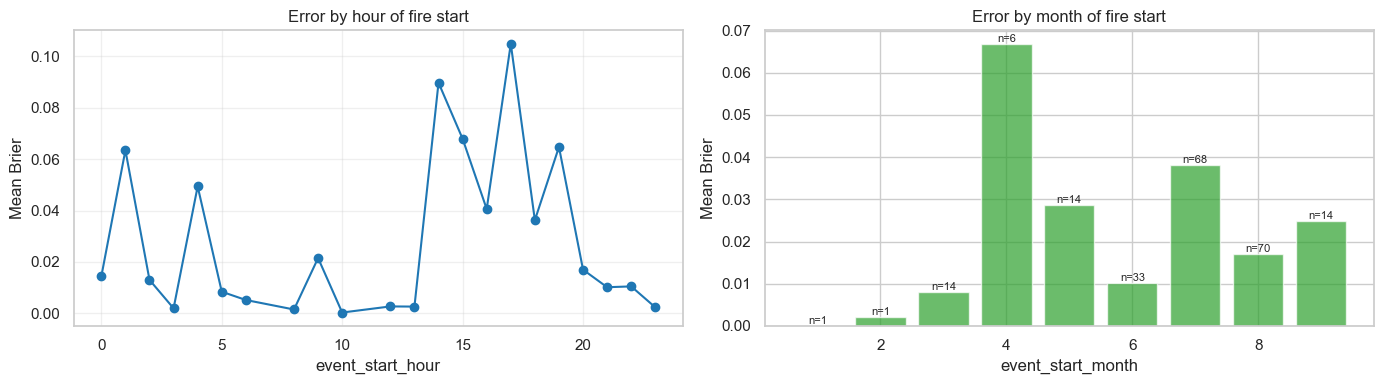

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Error by hour of day
hour_err = err_df.groupby("event_start_hour").agg(
    brier=("brier_sample", "mean"),
    n=("brier_sample", "count"),
)
axes[0].plot(hour_err.index, hour_err["brier"], "o-", color="tab:blue")
axes[0].set_xlabel("event_start_hour")
axes[0].set_ylabel("Mean Brier")
axes[0].set_title("Error by hour of fire start")
axes[0].grid(True, alpha=0.3)

# Error by month
month_err = err_df.groupby("event_start_month").agg(
    brier=("brier_sample", "mean"),
    n=("brier_sample", "count"),
)
axes[1].bar(month_err.index, month_err["brier"], color="tab:green", alpha=0.7)
for m, (v, n) in zip(month_err.index, zip(month_err["brier"], month_err["n"], strict=True), strict=True):
    axes[1].text(m, v + 0.0005, f"n={n}", ha="center", fontsize=8)
axes[1].set_xlabel("event_start_month")
axes[1].set_ylabel("Mean Brier")
axes[1].set_title("Error by month of fire start")

plt.tight_layout()
save_fig("error_temporal_patterns")
plt.show()

## 6. Calibration Curve at Each Horizon

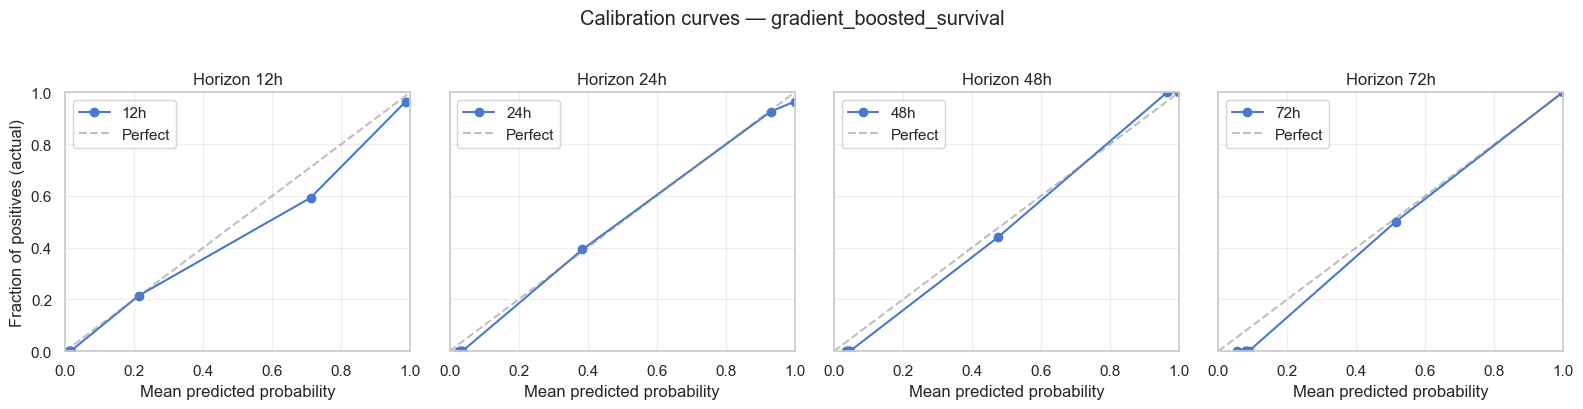

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for i, h in enumerate(HORIZONS):
    ax = axes[i]
    label = labels[:, i]
    pred = preds_arr[:, i]
    if len(np.unique(label)) > 1:
        frac_pos, mean_pred = calibration_curve(label, pred, n_bins=8, strategy="quantile")
        ax.plot(mean_pred, frac_pos, "o-", label=f"{h}h")
    ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5, label="Perfect")
    ax.set_xlabel("Mean predicted probability")
    if i == 0:
        ax.set_ylabel("Fraction of positives (actual)")
    ax.set_title(f"Horizon {h}h")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")

plt.suptitle(f"Calibration curves — {best_name}", y=1.02)
plt.tight_layout()
save_fig("error_calibration_by_horizon")
plt.show()

## 7. Surprising Hits and Near-Misses

Two failure modes to inspect:

- **False negatives at 72h**: the fire actually hit but we predicted low probability.
- **False positives at 72h**: we predicted high probability but it was censored.

In [8]:
false_negs = err_df[(err_df["label_72h"] == 1) & (err_df["pred_72h"] < 0.3)]
false_pos = err_df[(err_df["label_72h"] == 0) & (err_df["pred_72h"] > 0.7)]

print(f"False negatives at 72h (missed hits): {len(false_negs)} samples")
if len(false_negs) > 0:
    print(false_negs[
        ["event_id", "time_to_hit_hours", "pred_72h",
         "dist_min_ci_0_5h", "closing_speed_m_per_h", "alignment_abs"]
    ].round(3).to_string(index=False))

print(f"\nFalse positives at 72h (false alarms): {len(false_pos)} samples")
if len(false_pos) > 0:
    print(false_pos[
        ["event_id", "time_to_hit_hours", "pred_72h",
         "dist_min_ci_0_5h", "closing_speed_m_per_h", "alignment_abs"]
    ].round(3).to_string(index=False))

False negatives at 72h (missed hits): 0 samples

False positives at 72h (false alarms): 0 samples


## 8. Documented Error Patterns

Based on the analyses above, three systematic error patterns emerge (fill in after running):

1. **Distance-band concentration** — Section 4 shows where most error mass sits (typically mid-to-far distances where the signal is weakest).
2. **Rare-event horizons** — at 12h, the positive class is tiny (often <10 events in CV), so the learned calibration is noisy; Section 6 calibration curves should show the tightest deviation here.
3. **Static (non-moving) fires** — Worst-10% feature profile (Section 3) often shows `is_closing=0`, `closing_speed` near zero, and `area_growth_abs_0_5h=0`. The model has no kinetic signal to exploit and defaults to the marginal rate, producing middling predictions that score poorly when the fire does hit late.

These insights are recorded in `docs/modeling_decisions.md` under "Phase 6 Error Analysis".